# Task #2: BBC Sports News Classification

### Loading dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

data_path = '/content/drive/My Drive/datasets/bbcsports.csv'
df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,text,label
0,0,Sharapova overcomes tough Molik\n\nWimbledon c...,tennis
1,1,GB players warned over security\n\nBritain's D...,tennis
2,2,Federer wins title in Rotterdam\n\nWorld numbe...,tennis
3,3,Mauresmo fights back to win title\n\nWorld num...,tennis
4,4,Agassi into second round in Dubai\n\nFourth se...,tennis


In [3]:
df.shape

(737, 3)

### Number of instances in each class label

In [4]:
df['label'].value_counts()

,count
label,
football,265
rugby,147
cricket,124
athletics,101
tennis,100


### Preparing the data

Using tokenizer to convert each news story into a sequence of word indices and then converting  every sequence into a 0/1 vector (multi-hot encoding).

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer

num_words = 10000
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
sequences[0]

[1678,
 5498,
 430,
 1754,
 724,
 207,
 2472,
 1678,
 1679,
 26,
 467,
 1,
 350,
 94,
 2,
 53,
 1,
 85,
 6,
 1,
 2060,
 174,
 1,
 72,
 321,
 202,
 294,
 1680,
 269,
 2473,
 1754,
 205,
 70,
 70,
 131,
 70,
 205,
 7,
 91,
 72,
 208,
 6,
 1,
 49,
 1754,
 37,
 30,
 3363,
 157,
 321,
 3364,
 1967,
 5,
 2061,
 527,
 85,
 756,
 1678,
 5,
 1,
 175,
 41,
 6,
 3,
 35,
 94,
 90,
 270,
 9,
 2,
 53,
 13,
 1678,
 1679,
 2,
 837,
 43,
 3,
 3080,
 228,
 201,
 248,
 5,
 1,
 72,
 94,
 4,
 90,
 246,
 351,
 59,
 28,
 15,
 1754,
 457,
 91,
 41,
 2062,
 2063,
 25,
 1678,
 756,
 5,
 1,
 610,
 41,
 6,
 1,
 1681,
 2,
 248,
 138,
 154,
 4,
 431,
 1754,
 2834,
 5,
 1024,
 1678,
 518,
 9,
 2,
 91,
 647,
 4,
 100,
 537,
 65,
 1,
 68,
 14,
 34,
 2835,
 28,
 3365,
 3,
 244,
 304,
 5,
 1,
 3081,
 41,
 1678,
 22,
 1,
 698,
 2,
 91,
 141,
 12,
 91,
 553,
 1184,
 28,
 467,
 1,
 35,
 94,
 2473,
 12,
 8847,
 1386,
 2,
 103,
 5,
 1,
 35,
 94,
 13,
 5,
 69,
 903,
 10,
 12,
 258,
 553,
 22,
 1678,
 5,
 1,
 35,
 94,
 10,
 12

**Encoding input data**

In [6]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            if j < dimension:
                results[i, j] = 1.
    return results

x_data = vectorize_sequences(sequences, num_words)
x_data[33]

array([0., 1., 1., ..., 0., 0., 0.])

**Encoding labels**

In [7]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_integers = label_encoder.fit_transform(df['label'])
y_data = to_categorical(y_integers)
y_data[100]

array([0., 0., 0., 1., 0.])

### Splitting data 80% train, 20% test

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data,
    test_size=0.2,
    stratify=y_integers,
    random_state=42
)

x_train.shape, x_test.shape

((589, 10000), (148, 10000))

**validation set**

In [9]:
x_val = x_train[:60]
partial_x_train = x_train[60:]
y_val = y_train[:60]
partial_y_train = y_train[60:]

### Building model

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(5, activation="softmax")
])
model.summary()
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Training model**

In [11]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=10,
                    batch_size=16,
                    validation_data=(x_val, y_val))

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7750 - loss: 0.8186 - val_accuracy: 0.9667 - val_loss: 0.2190
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9924 - loss: 0.0848 - val_accuracy: 0.9833 - val_loss: 0.0677
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0352
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0236
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 6.0345e-04 - val_accuracy: 1.0000 - val_loss: 0.0197
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 2.7661e-04 - val_accuracy: 1.0000 - val_loss: 0.0179
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 1.6832e-04 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 1.1696e-04 - val_accurac

**Plotting training and validation loss**

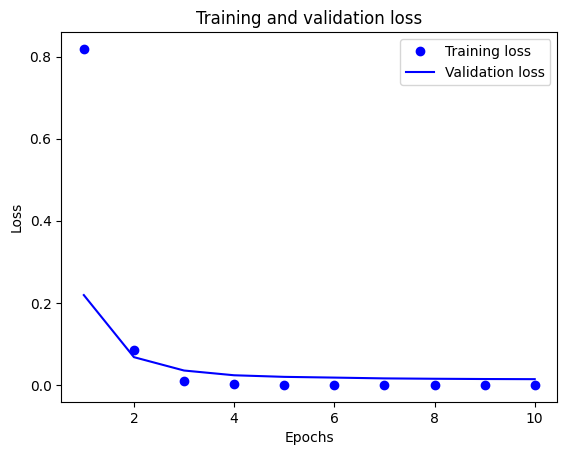

In [12]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Plotting training and validation accuracy**

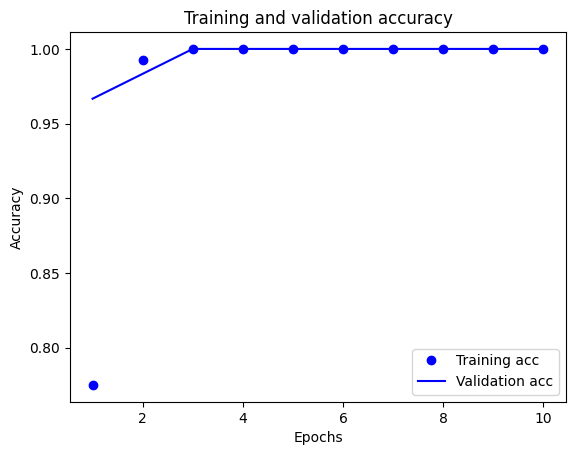

In [13]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Training and test accuracy

In [14]:
train_results = model.evaluate(x_train, y_train)
print(f"Training accuracy: {train_results[1]}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0015
Training accuracy: 1.0


In [15]:
test_results = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_results[1]}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9865 - loss: 0.0545
Test accuracy: 0.9864864945411682


###Question: Does accuracy vary from class to class label?

In [16]:
from sklearn.metrics import classification_report

predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

   athletics       1.00      1.00      1.00        20
     cricket       1.00      0.96      0.98        25
    football       0.96      1.00      0.98        53
       rugby       1.00      0.97      0.98        30
      tennis       1.00      1.00      1.00        20

    accuracy                           0.99       148
   macro avg       0.99      0.99      0.99       148
weighted avg       0.99      0.99      0.99       148



**Answer:**

Accuracy differs across classes mainly because some sports like `football` have far more training examples than others like `tennis` or `athletics`, and sports that share similar vocabulary like `rugby` and `football`, both using words like 'try', 'tackle', 'match' are easier for the model to mix up.